In [2]:
# EDA
import sys
import os
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from pathlib import Path
from pandas.plotting import scatter_matrix

joined = pd.read_csv("datasets/dataset_joined.csv")
cleaned = pd.read_csv("datasets/dataset_cleaned.csv")

%matplotlib inline

In [3]:
print("(# of Rows, # of Columns for Cleaned Data):", cleaned.shape) 
print("(# of Rows, # of Columns for Joined Data):", joined.shape) 
print("\nCleaned Data Types:\n", cleaned.dtypes) # types: object, float64, int64
print("\nJoined Data Types:\n", joined.dtypes)

display(joined.head(3))
display(cleaned.head(3))

(# of Rows, # of Columns for Cleaned Data): (6591, 57)
(# of Rows, # of Columns for Joined Data): (13777, 28)

Cleaned Data Types:
 latitude                              float64
longitude                             float64
price                                  object
beds                                    int64
baths                                 float64
sq_feet                                 int64
cats                                    int64
dogs                                    int64
nearestSchool                         float64
nearestPolice                         float64
restaurantCount                         int64
cemeteryCount                           int64
healthCareCount                         int64
communityCentreCount                    int64
placeOfWorshipCount                     int64
leisureCount                            int64
shopCount                               int64
tourismCount                            int64
lease_term_12 months                    

,rentfaster_id,city,province,address,latitude,longitude,lease_term,type,price,beds,...,nearestSchool,nearestPolice,restaurantCount,cemeteryCount,healthCareCount,communityCentreCount,placeOfWorshipCount,leisureCount,shopCount,tourismCount
0,468622,Airdrie,Alberta,69 Gateway Dr NE,51.305962,-114.012515,Long Term,Townhouse,2495.0,2 Beds,...,0.333439,16.725785,2,0,1,0,0,5,0,0
1,468622,Airdrie,Alberta,69 Gateway Dr NE,51.305962,-114.012515,Long Term,Townhouse,2695.0,3 Beds,...,0.333439,16.725785,2,0,1,0,0,5,0,0
2,468622,Airdrie,Alberta,69 Gateway Dr NE,51.305962,-114.012515,Long Term,Townhouse,2295.0,2 Beds,...,0.333439,16.725785,2,0,1,0,0,5,0,0


,latitude,longitude,price,beds,baths,sq_feet,cats,dogs,nearestSchool,nearestPolice,...,sq_feet_standardized,nearestSchool_standardized,nearestPolice_standardized,restaurantCount_standardized,cemeteryCount_standardized,healthCareCount_standardized,placeOfWorshipCount_standardized,leisureCount_standardized,shopCount_standardized,tourismCount_standardized
0,51.305962,-114.012515,>=2000,2,2.5,1403,1,1,0.333439,16.725785,...,0.695746,-0.69548,0.504273,-0.675212,-0.012318,-0.966382,-0.739647,-0.086843,-0.750203,-0.567558
1,51.305962,-114.012515,>=2000,3,2.5,1496,1,1,0.333439,16.725785,...,0.860128,-0.69548,0.504273,-0.675212,-0.012318,-0.966382,-0.739647,-0.086843,-0.750203,-0.567558
2,51.305962,-114.012515,>=2000,2,2.5,1180,1,1,0.333439,16.725785,...,0.301584,-0.69548,0.504273,-0.675212,-0.012318,-0.966382,-0.739647,-0.086843,-0.750203,-0.567558


Price class counts (cleaned):


price
<2000     3603
>=2000    2988
Name: count, dtype: int64

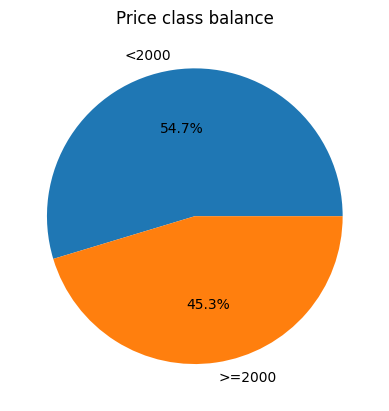

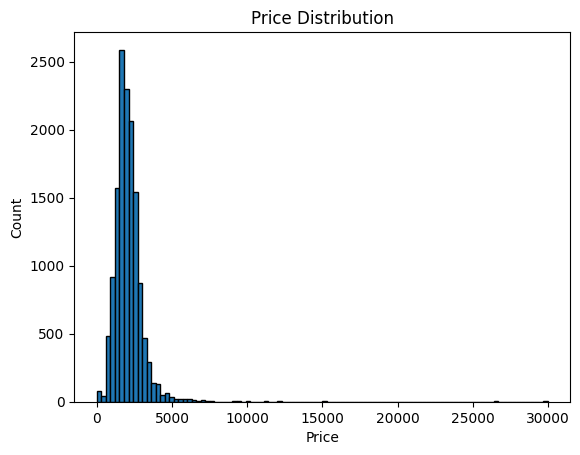

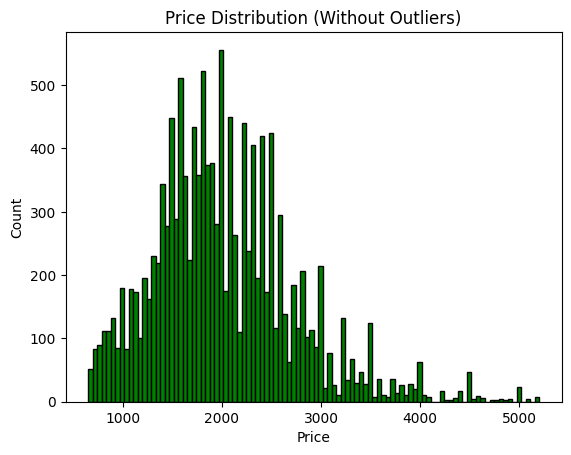

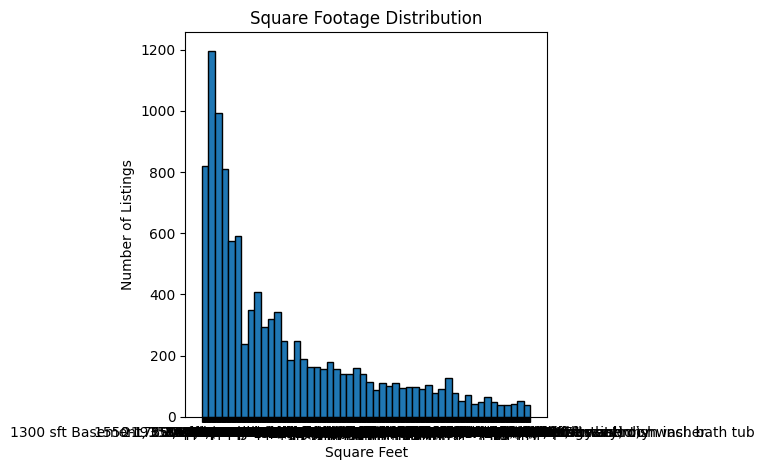

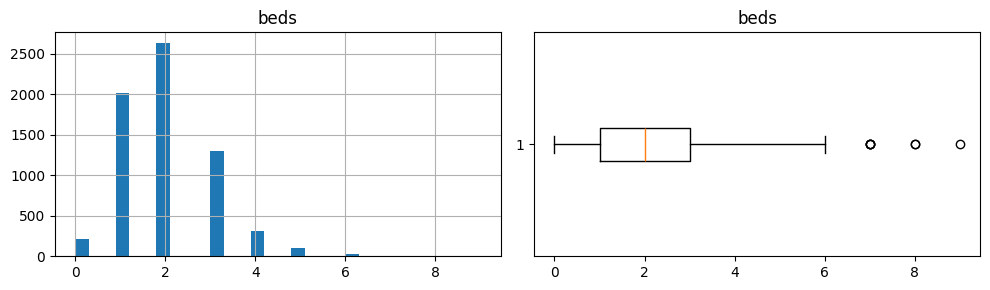

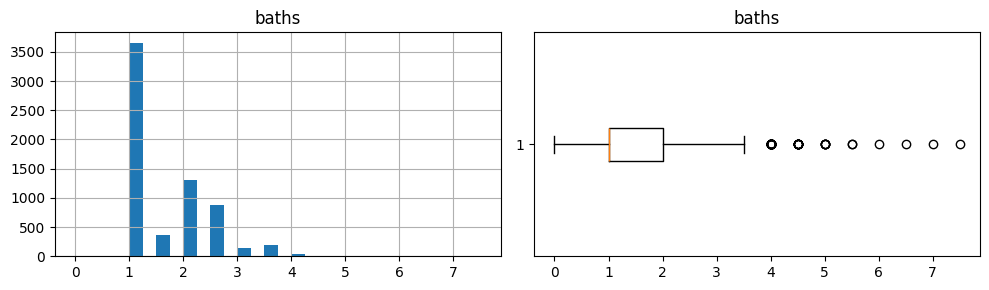

In [4]:
print("Price class counts (cleaned):")
joined['price'] = pd.to_numeric(joined['price'], errors='coerce')
display(cleaned["price"].value_counts())
cleaned["price"].value_counts().plot.pie(autopct="%1.1f%%", ylabel="", title="Price class balance")
plt.show()

plt.hist(joined["price"].dropna(), bins=100, edgecolor="black")
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

low, high = np.percentile(joined["price"], [1, 99])
price_clean = joined["price"][(joined["price"] >= low) & (joined["price"] <= high)]

# histogram without outliers
plt.hist(price_clean, bins=100, color="green", edgecolor="black")
plt.title("Price Distribution (Without Outliers)")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

plt.hist(joined["sq_feet"].dropna(), bins=50, edgecolor="black")
plt.title("Square Footage Distribution")
plt.xlabel("Square Feet")
plt.ylabel("Number of Listings")
plt.tight_layout()
plt.show()

num_cols = ['beds','baths']
for c in num_cols:
    fig, axs = plt.subplots(1,2, figsize=(10,3))
    cleaned[c].hist(ax=axs[0], bins=30)
    axs[0].set_title(f"{c}")
    axs[1].boxplot(cleaned[c].dropna(), vert=False)
    axs[1].set_title(f"{c}")
    plt.tight_layout()
    plt.show()

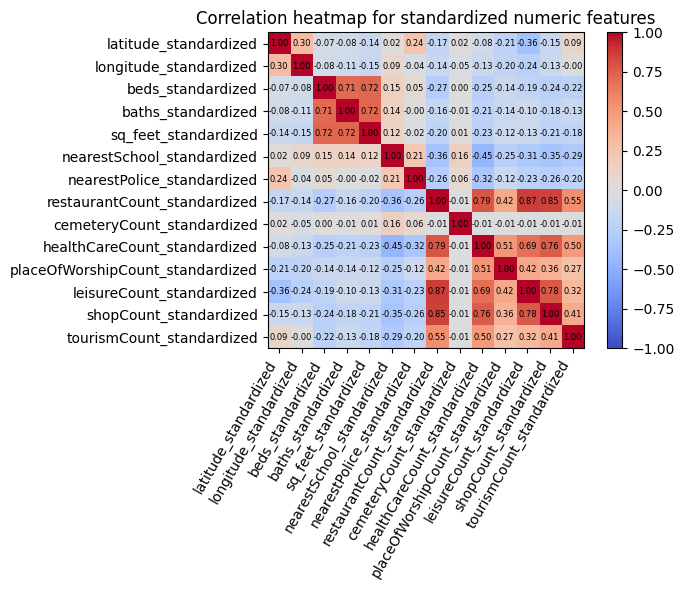

Pairs with |corr| >= 0.60:
beds_standardized and baths_standardized : 0.705
beds_standardized and sq_feet_standardized : 0.719
baths_standardized and sq_feet_standardized : 0.724
restaurantCount_standardized and healthCareCount_standardized : 0.788
restaurantCount_standardized and leisureCount_standardized : 0.872
restaurantCount_standardized and shopCount_standardized : 0.852
healthCareCount_standardized and leisureCount_standardized : 0.691
healthCareCount_standardized and shopCount_standardized : 0.759
leisureCount_standardized and shopCount_standardized : 0.781


In [5]:
std_cols = [c for c in cleaned.columns if c.endswith("_standardized")]
corr = cleaned[std_cols].corr()

fig, ax = plt.subplots(figsize=(8,6))
heatmap = ax.imshow(corr.values, vmin=-1, vmax=1, cmap= "coolwarm")
ax.set_xticks(range(len(std_cols))); ax.set_xticklabels(std_cols, rotation=60, ha="right")
ax.set_yticks(range(len(std_cols))); ax.set_yticklabels(std_cols)

for i in range(len(std_cols)):
    for j in range(len(std_cols)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=6)
fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)
plt.title("Correlation heatmap for standardized numeric features")
plt.tight_layout()
plt.show()

# list high correlation pairs based on set thershold
threshold = 0.6
pairs = []
for i in range(len(std_cols)):
    for j in range(i+1, len(std_cols)):
        v = corr.iloc[i,j]
        if abs(v) >= threshold:
            pairs.append((std_cols[i], std_cols[j], v))
print("Pairs with |corr| >= {:.2f}:".format(threshold))
for p in pairs:
    print(p[0], "and", p[1], ":", round(p[2],3))

Type counts:


type_Apartment        2747
type_Condo Unit       1016
type_House             705
type_Townhouse         672
type_Basement          636
type_Main Floor        364
type_Duplex            234
type_Room For Rent     202
type_Loft               12
type_Vacation Home       2
type_Mobile              1
dtype: int64

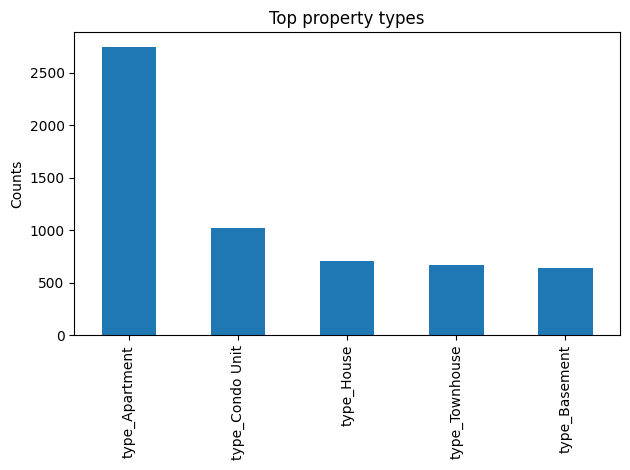

Furnishing counts:


furnishing_Furnished                   750
furnishing_Negotiable                  178
furnishing_Unfurnished                5660
furnishing_Unfurnished, Negotiable       3
dtype: int64

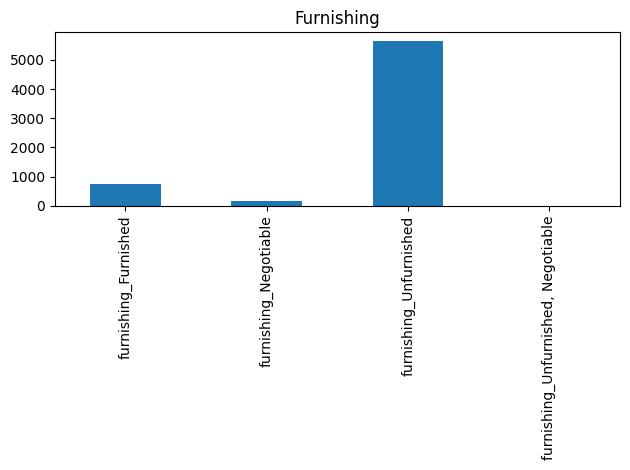

Lease term counts:


lease_term_Long Term     5781
lease_term_Negotiable     631
lease_term_Short Term     123
lease_term_12 months       54
lease_term_6 months         1
lease_term_months           1
dtype: int64

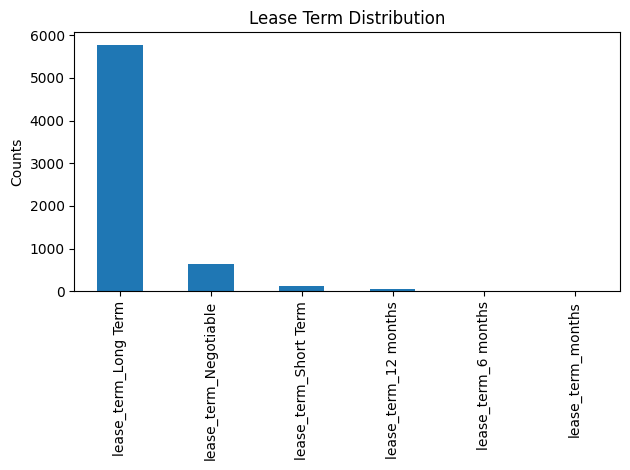

In [6]:
type_cols = [c for c in cleaned.columns if c.startswith("type_")]
type_counts = cleaned[type_cols].sum().sort_values(ascending=False)
print("Type counts:")
display(type_counts)
type_counts.head().plot.bar()
plt.title("Top property types")
plt.ylabel("Counts")
plt.tight_layout()
plt.show()

furn_cols = [c for c in cleaned.columns if c.startswith("furnishing_")]
furn_counts = cleaned[furn_cols].sum()
print("Furnishing counts:")
display(furn_counts)
furn_counts.plot.bar()
plt.title("Furnishing")
plt.tight_layout()
plt.show()

lease_cols = [c for c in cleaned.columns if c.startswith("lease_term_")]
lease_counts = cleaned[lease_cols].sum().sort_values(ascending=False)
print("Lease term counts:")
display(lease_counts)
lease_counts.plot.bar()
plt.title("Lease Term Distribution")
plt.ylabel("Counts")
plt.tight_layout()
plt.show()

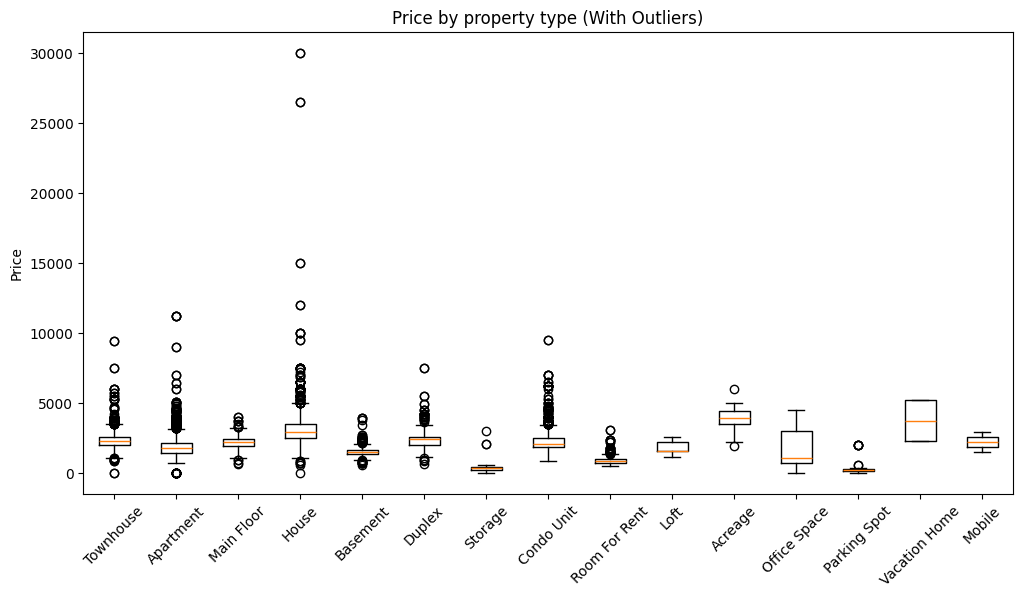

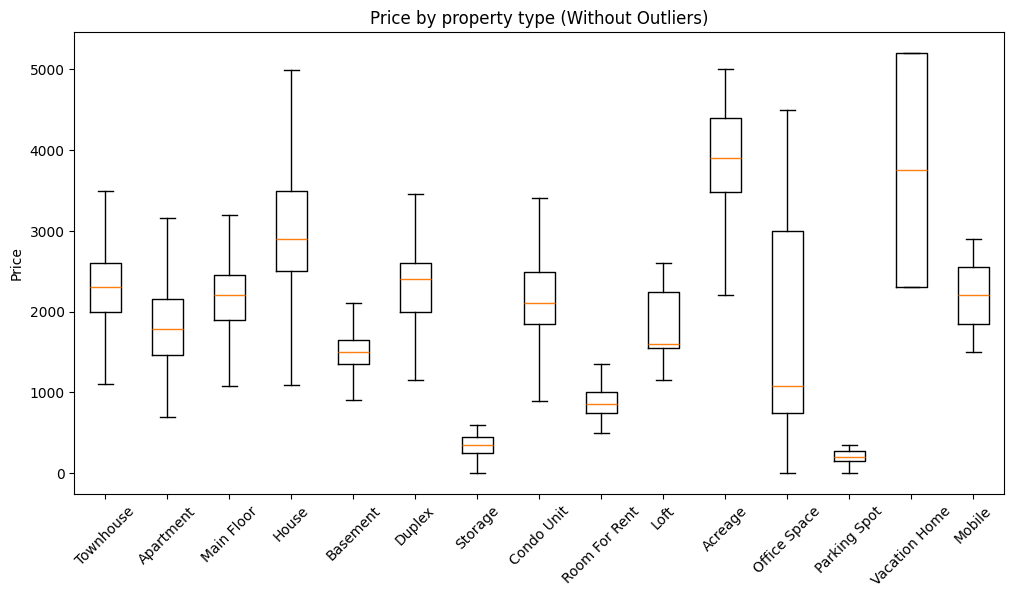

In [7]:
# boxplot to spot outliers and compare groups (price by property type)
property_types = joined["type"].dropna().unique().tolist()

# create a list of price arrays for each property type
data_for_box = [joined.loc[joined["type"] == t, "price"].dropna().values for t in property_types]

fig = plt.figure(figsize=(12,6))
plt.boxplot(data_for_box, tick_labels=property_types, showfliers=True, vert=True)
plt.title("Price by property type (With Outliers)")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()

fig = plt.figure(figsize=(12,6))
plt.boxplot(data_for_box, tick_labels=property_types, showfliers=False, vert=True)
plt.title("Price by property type (Without Outliers)")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()

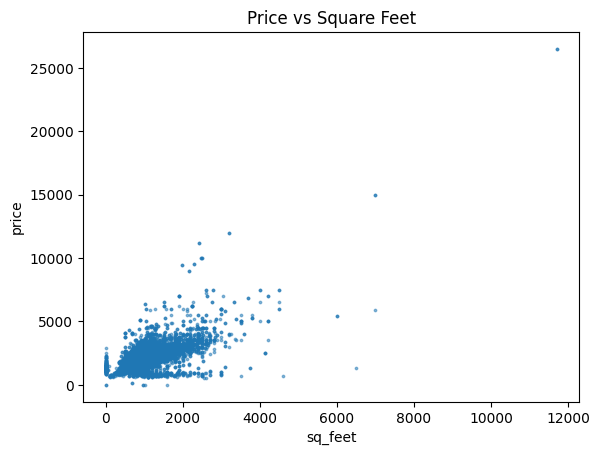

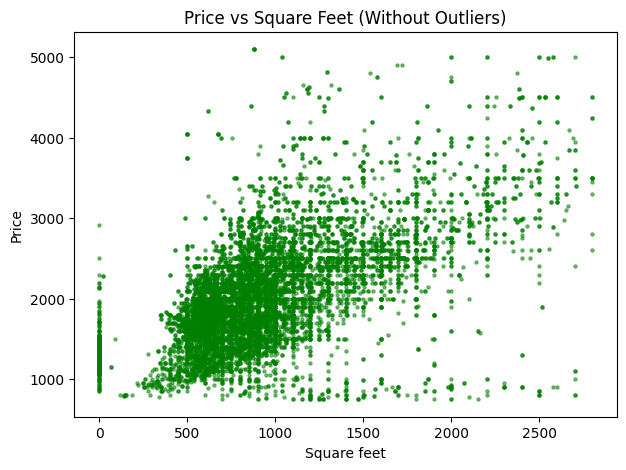

In [8]:
# ensure all our numeric first
joined["sq_feet"] = pd.to_numeric(joined["sq_feet"], errors="coerce")
joined["price"] = pd.to_numeric(joined["price"], errors="coerce")

mask = joined["price"].notnull() & joined["sq_feet"].notnull()

plt.scatter(joined.loc[mask, "sq_feet"], joined.loc[mask, "price"], s=3, alpha=0.5)
plt.xlabel("sq_feet")
plt.ylabel("price")
plt.title("Price vs Square Feet")


x = joined.loc[mask, "sq_feet"].values
y = joined.loc[mask, "price"].values
plt.show()

x_low, x_high = np.percentile(x, [1, 99])
y_low, y_high = np.percentile(y, [1, 99])

mask_no_outliers = (x >= x_low) & (x <= x_high) & (y >= y_low) & (y <= y_high)
x2 = x[mask_no_outliers]
y2 = y[mask_no_outliers]

plt.figure(figsize=(7,5))
plt.scatter(x2, y2, s=5, alpha=0.5, color="green")
plt.xlabel("Square feet")
plt.ylabel("Price")
plt.title("Price vs Square Feet (Without Outliers)")
plt.show()

In [9]:
q1 = joined["price"].quantile(0.25)
q3 = joined["price"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = joined[(joined["price"] < lower) | (joined["price"] > upper)]
print("IQR outlier thresholds:", lower, upper)
print("Outlier count:", len(outliers), "out of", len(joined), f"({len(outliers)/len(joined):.2%})")
display(outliers.sort_values("price", ascending=False).head(10))

IQR outlier thresholds: 217.5 3709.5
Outlier count: 539 out of 13777 (3.91%)


,rentfaster_id,city,province,address,latitude,longitude,lease_term,type,price,beds,...,nearestSchool,nearestPolice,restaurantCount,cemeteryCount,healthCareCount,communityCentreCount,placeOfWorshipCount,leisureCount,shopCount,tourismCount
4586,571693,Calgary,Alberta,13 Ave NE,51.064172,-114.049670,Short Term,House,29990.0,3 Beds,...,2.751645,2.376172,58,0,12,0,1,4,5,4
13244,571693,Calgary,Alberta,13 Ave NE,51.064172,-114.049670,Short Term,House,29990.0,3 Beds,...,2.751645,2.376172,58,0,12,0,1,4,5,4
10939,490755,Calgary,Alberta,Springbank Hill,51.028096,-114.195080,Negotiable,House,26500.0,8 Beds,...,4.190954,9.171806,11,0,0,0,0,1,0,0
2291,490755,Calgary,Alberta,Springbank Hill,51.028096,-114.195080,Negotiable,House,26500.0,8 Beds,...,4.190954,9.171806,11,0,0,0,0,1,0,0
11101,535326,Calgary,Alberta,79 Bel-Aire Place SW,50.998793,-114.093004,12 months,House,14995.0,3 Beds,...,2.269509,1.400589,43,0,11,0,0,4,16,0
2460,535326,Calgary,Alberta,79 Bel-Aire Place SW,50.998793,-114.093004,12 months,House,14995.0,3 Beds,...,2.269509,1.400589,43,0,11,0,0,4,16,0
1328,440585,Calgary,Alberta,1209 Riverdale Avenue Southwest,51.016810,-114.088027,Negotiable,House,12000.0,4 Beds,...,2.014831,2.390567,22,0,2,0,3,9,5,0
9987,440585,Calgary,Alberta,1209 Riverdale Avenue Southwest,51.016810,-114.088027,Negotiable,House,12000.0,4 Beds,...,2.014831,2.390567,22,0,2,0,3,9,5,0
223,483743,Calgary,Alberta,524 10th Ave,51.043668,-114.072088,Long Term,Apartment,11200.0,2 Beds,...,0.770906,0.428378,417,0,29,0,2,22,54,10
8870,483743,Calgary,Alberta,524 10th Ave,51.043668,-114.072088,Long Term,Apartment,11200.0,2 Beds,...,0.770906,0.428378,417,0,29,0,2,22,54,10


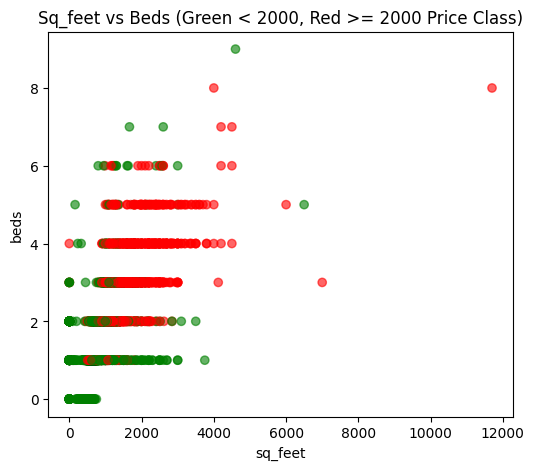

In [10]:
fig, ax = plt.subplots(figsize=(6,5))
colors = cleaned['price'].map({'>=2000':'red','<2000':'green'})
ax.scatter(cleaned['sq_feet'], cleaned['beds'], c=colors, alpha=0.6)
ax.set_xlabel('sq_feet'); ax.set_ylabel('beds')
ax.set_title('Sq_feet vs Beds (Green < 2000, Red >= 2000 Price Class)')
plt.show()

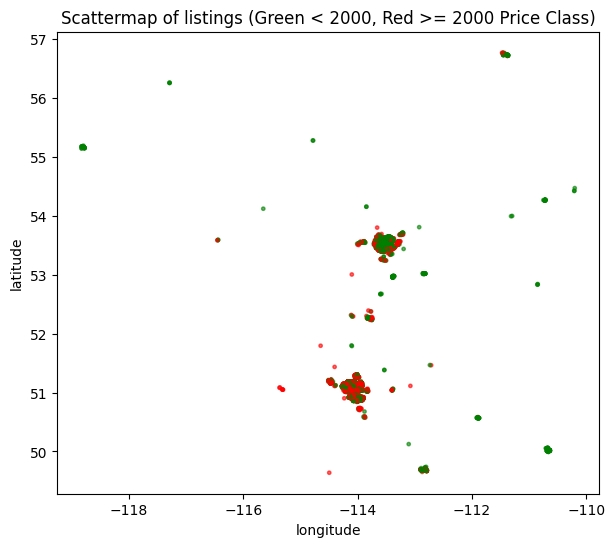

In [11]:
plt.figure(figsize=(7,6))
classes = {'>=2000':'red','<2000':'green'}
plt.scatter(cleaned['longitude'], cleaned['latitude'], c=cleaned['price'].map(classes), s=6, alpha=0.6)
plt.xlabel("longitude"); plt.ylabel("latitude")
plt.title("Scattermap of listings (Green < 2000, Red >= 2000 Price Class)")
plt.show()

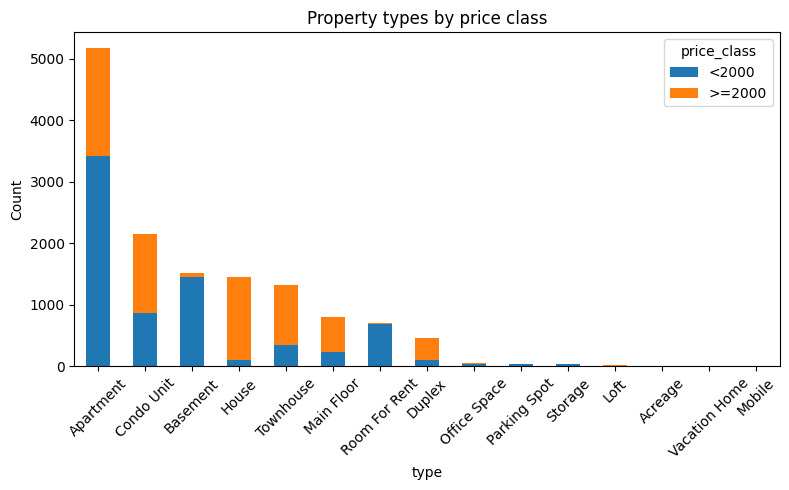

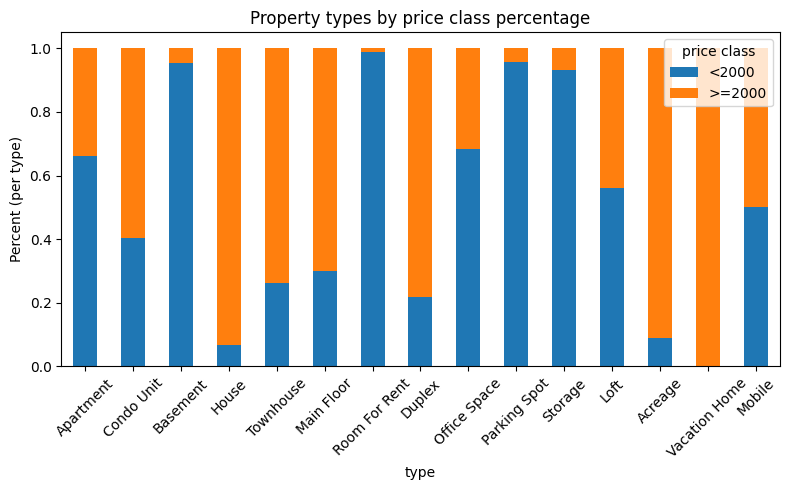

In [12]:
joined['price_class'] = pd.cut(joined['price'], bins=[-1,1999,1e9], labels=['<2000','>=2000'])
ct = pd.crosstab(joined['type'], joined['price_class'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) 

property_types = ct.sum(axis=1).sort_values(ascending=False).index.tolist()
ct.loc[property_types].plot(kind='bar', stacked=True, figsize=(8,5))
plt.ylabel("Count")
plt.title("Property types by price class")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# show percent version too
ct_pct.loc[property_types].plot(kind='bar', stacked=True, figsize=(8,5))
plt.ylabel("Percent (per type)")
plt.title("Property types by price class percentage")
plt.legend(title='price class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

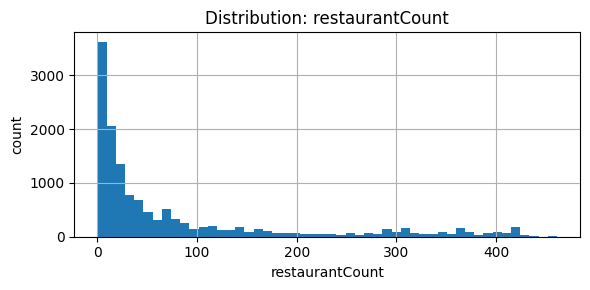

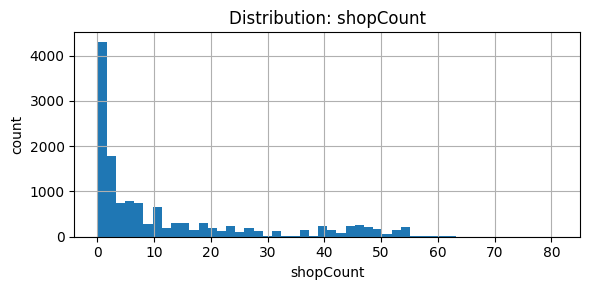

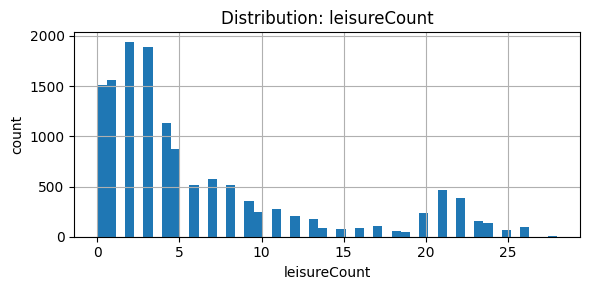

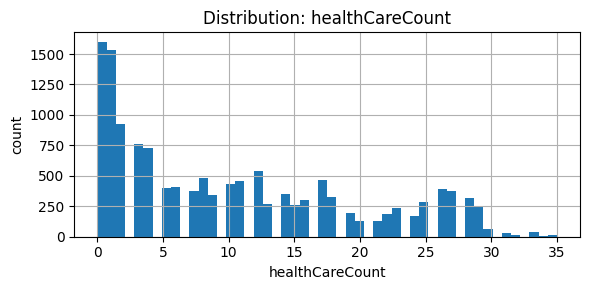

In [13]:
# highly correlated ones
amen_cols = ['restaurantCount','shopCount','leisureCount','healthCareCount']
for c in amen_cols:
    plt.figure(figsize=(6,3))
    joined[c].hist(bins=50)
    plt.title(f"Distribution: {c}")
    plt.xlabel(c); plt.ylabel("count")
    plt.tight_layout()
    plt.show()

EDA first focused on data completeness along with an overview of variable types and data summaries, then on pairwise relationships that are relevant for clustering and later modeling. Standardization and null-handling were applied in preprocessing so that the numeric features used for clustering are on a comparable scale. The distribution of key numeric fields shows substantial right skew for counts such as restaurantCount and shopCount, where a small number of listings have extremely high counts, while geographical features like latitude/longitude appear reasonable enough for geographic plotting. The skew and a few very large values, such as, extremely high sqft listings, indicate the presence of outliers that should be examined more closely in the outlier stage.

Loaded two datasets: dataset_joined.csv, the joined RentFaster and OSM-derived amenity features, and dataset_cleaned.csv, which is cleaned, encoded, and standardized version used for modeling. The cleaned set contains numeric features (ie. beds, baths, sq_feet, nearest amenity distances, and amenity counts) and one-hot encoded categorical features (type, furnishing, lease terms).

The binary target was created at a threshold of $2,000: cleaned data shows 3,603 listings <2000 (54.7%) and 2,988 listings >=2000 (45.3%), showing a reasonably normal balance.

Using the IQR method, roughly 4% (539) price outliers wre found, which is reasonable but should still be looked at in the future. Boxplots also reveal outliers that may either reflect real, rare listings or data errors, that require further analysis and considieration in future stages.

The correlation heatmap shows the strongest linear relationships among certain standardized numeric features (ie. sq_feet and beds, restaurantCount and shopCount, etc.) These pairs are often positively correlated because denser commercial areas tend to have more amenity types, and that larger housing units will naturally have more beds and baths. Amenity counts are also strongly correlated with eachother, which is again reasonable due to the natural urban layouts of cities.

Scatter maps of latitude/longitude colored by price classes show geographic clustering of priced listings, which are useful indicators of urban and suburban areas. These can be looked into further in later stages as well.



X shape (n_samples, n_features): (6405, 14)
PCA reduced shape:  (6405, 9)
Explained variance (sum): 0.928


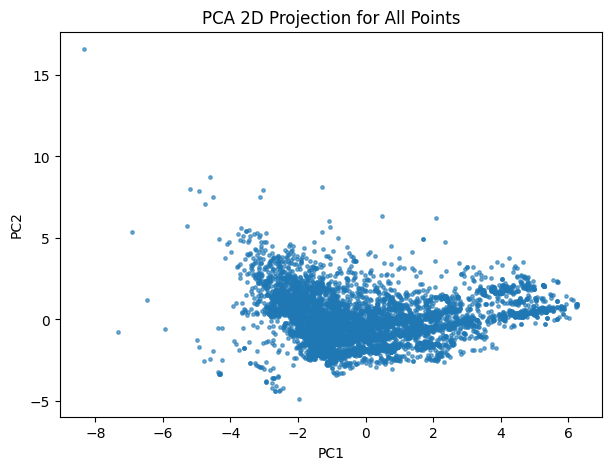

In [15]:
# Clustering and Outliers
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

seed = 0
random.seed(seed)
np.random.seed(seed)
cleaned = pd.read_csv("datasets/dataset_cleaned.csv")

std_candidates = [c for c in cleaned.columns if c.endswith('standardized')]
std_candidates = [c for c in std_candidates if cleaned[c].std() > 0.001] # drop any near zero values

final_features = [
    'latitude_standardized', 'longitude_standardized', 'beds_standardized',
    'baths_standardized', 'sq_feet_standardized', 'nearestSchool_standardized',
    'nearestPolice_standardized', 'restaurantCount_standardized', 'cemeteryCount_standardized',
    'healthCareCount_standardized', 'placeOfWorshipCount_standardized',
    'leisureCount_standardized', 'shopCount_standardized', 'tourismCount_standardized'
]
# keep only those that actually exist after your preprocessing
final_features = [f for f in final_features if f in std_candidates]

# Make df_for_clustering (drop rows with missing entries in chosen features)
mask = cleaned[final_features].notnull().all(axis=1)
df_for_clustering = cleaned.loc[mask].reset_index(drop=True).copy()

# sq feet values of 0 are dropped
if 'sq_feet' in df_for_clustering.columns:
    n_zero = int((df_for_clustering['sq_feet'] == 0).sum())
    if n_zero > 0:
        df_for_clustering = df_for_clustering.loc[df_for_clustering['sq_feet'] != 0].reset_index(drop=True)
    
scaler = StandardScaler()
X = scaler.fit_transform(df_for_clustering[final_features].values)
print("X shape (n_samples, n_features):", X.shape)

# PCA (preserve 90% variance for clustering, and a 2D PCA for plotting)
pca = PCA(n_components=0.90, svd_solver='full', random_state=seed)
X_pca = pca.fit_transform(X)
print("PCA reduced shape: ", X_pca.shape)
print("Explained variance (sum):", pca.explained_variance_ratio_.sum().round(3))

# 2D PCA projection for visualization
pca2 = PCA(n_components=2, svd_solver='full', random_state=seed)
X_pca2 = pca2.fit_transform(X)  # used only for quick 2D plotting
plt.figure(figsize=(7,5))
plt.scatter(X_pca2[:,0], X_pca2[:,1], s=6, alpha=0.6)
plt.title("PCA 2D Projection for All Points")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()



To make clustering more manageable, we standardize numeric features and reduce dimensionality with PCA:

We select a stable set of standardized numeric features, drop zero-variance columns, scale to zero mean/unit variance, then apply PCA. The PCA projection preserves the majority of variance while reducing dimensionality, which removes linear redundancy between correlated features like sq_feet and beds, reduces noise, and speeds neighbourhood queries for density-based clustering.

From the preprocessing step: the feature matrix used for clustering (X) has shape (6405, 14) and the PCA embedding used for clustering (X_pca) has shape (6405, 9) with cumulative explained variance ≈ 0.928, so PCA retains ~92.8% of the original variance

Clustering on the PCA space strikes a balance between preserving structure and preventing distance measures from being dominated by highly correlated raw features.

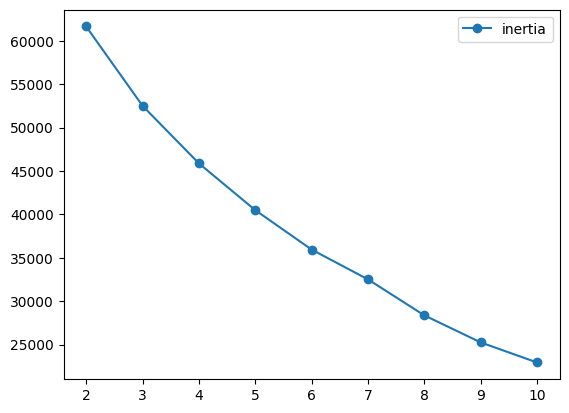

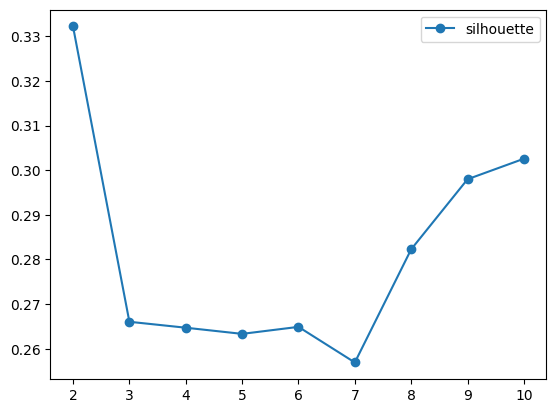

In [17]:
inertias = []
silhs = []
k_range = list(range(2,11))

for k in k_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=seed)
    labels = km.fit_predict(X_pca) # run on PCA reduced data for stability
    inertias.append(km.inertia_)
    silhs.append(silhouette_score(X_pca, labels))

plt.plot(k_range, inertias, '-o', label='inertia'); plt.legend()
plt.show()
plt.plot(k_range, silhs, '-o', label='silhouette'); plt.legend()
plt.show()

KMeans was run on the PCA space (X_pca) for k from 2 to 10 to assess cluster structure and limit the influence of highly correlated raw features and to accelerate neighborhood queries. We selected the number of clusters k using silhouette score measured in the same PCA space. For each k we computed the validation metrics Silhouette Score, Calinski–Harabasz (CH) Index , and Davies–Bouldin (DB) index. Computing these in the same PCA space keeps the comparisons consistent. The final KMeans model using an n_init=50 and a fixed seed for random_state. The results summarized indicate two broad segments: a larger segment with larger unit sizes but lower amenity density on average, and a smaller segment with smaller units yet a slightly larger proportion of listings in the higher price class. Notably, cluster 1 has a very high mean restaurantCount (≈216), which suggests either an extremely amenity-dense cluster, which is very reasonable when examining regions such as a downtown sector. The cluster separation metrics indicate moderate and usable separation between the two clusters.


In [19]:
# pick best k by silhouette
best_k = k_range[int(np.argmax(silhs))]
print("Best k by silhouette:", best_k)

# Fit final KMeans and attach labels to df_for_clustering
km = KMeans(n_clusters=best_k, n_init=50, random_state=seed)
km_labels = km.fit_predict(X_pca)
df_for_clustering['kmeans_cluster'] = km_labels

# cluster metrics on PCA space
if len(set(km_labels)) > 1:
    sil_km = silhouette_score(X_pca, km_labels)
    ch_km = calinski_harabasz_score(X_pca, km_labels) 
    db_km = davies_bouldin_score(X_pca, km_labels)
else:
    sil_km = np.nan
    ch_km = np.nan
    db_km = np.nan
print("KMeans metrics => silhouette: {:.3f}, Calinski-Harabasz: {:.1f}, Davies-Bouldin: {:.3f}".format(sil_km, ch_km, db_km))

Best k by silhouette: 2
KMeans metrics => silhouette: 0.332, Calinski-Harabasz: 2237.7, Davies-Bouldin: 1.279


The selection picked best_k = 2. The KMeans fit got values of: Silhouette = 0.332, Calinski–Harabasz = 2237.7, Davies–Bouldin = 1.279; so moderate cluster separation, which is expected in housing data where there aren't clear and obvious socio-economic boundaries set

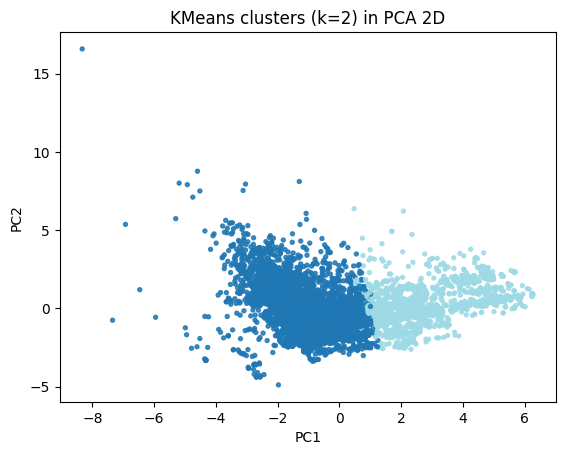

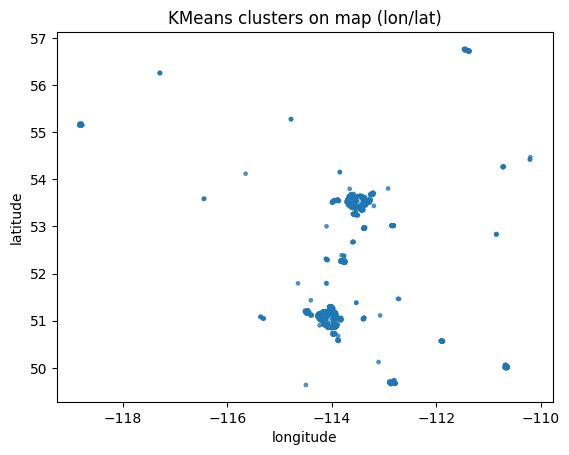

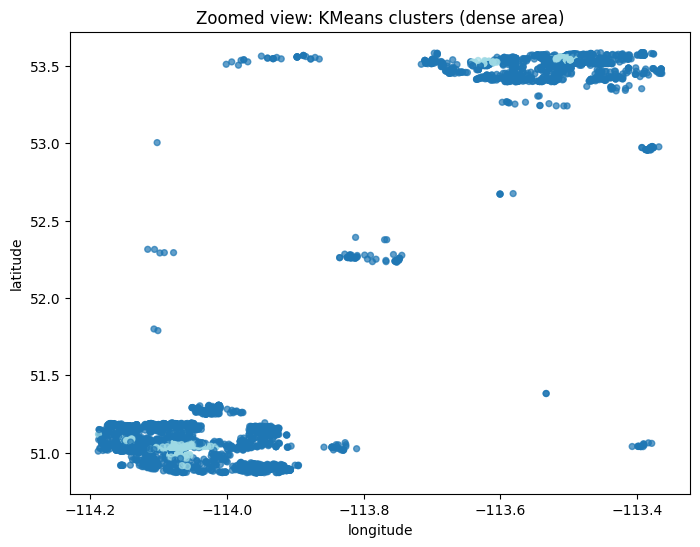

In [21]:
# PCA with colour
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=km_labels, cmap='tab20', s=8, alpha=0.85)
plt.title(f"KMeans clusters (k={best_k}) in PCA 2D")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

# geographic scatter with longitude latitude
plt.scatter(df_for_clustering['longitude'], df_for_clustering['latitude'], c=km_labels, cmap= 'tab20', s=6, alpha=0.7)
plt.title("KMeans clusters on map (lon/lat)")
plt.xlabel("longitude"); plt.ylabel("latitude")
plt.show()

# -- Zoom into the densest area, centered around the 10%-90% box
lat_min, lat_max = df_for_clustering['latitude'].quantile(0.05), df_for_clustering['latitude'].quantile(0.95)
lon_min, lon_max = df_for_clustering['longitude'].quantile(0.05), df_for_clustering['longitude'].quantile(0.95)

zoom_mask = (df_for_clustering['latitude'].between(lat_min, lat_max)) & (df_for_clustering['longitude'].between(lon_min, lon_max))
plt.figure(figsize=(8,6))
plt.scatter(df_for_clustering.loc[zoom_mask,'longitude'], df_for_clustering.loc[zoom_mask,'latitude'],
            c=df_for_clustering.loc[zoom_mask,'kmeans_cluster'], cmap='tab20', s=18, alpha=0.7)
plt.title("Zoomed view: KMeans clusters (dense area)")
plt.xlabel("longitude"); plt.ylabel("latitude")
plt.show()


In [22]:
df_for_clustering['cluster'] = labels

# cluster sizes
print("Cluster sizes (KMeans):")
display(df_for_clustering['kmeans_cluster'].value_counts().sort_index())

# price class distribution per cluster
ct = pd.crosstab(df_for_clustering['kmeans_cluster'], df_for_clustering['price'], normalize='index')
print("Price class distribution per KMeans cluster (fraction):")
display(ct.round(3))

# avg stats per cluster
cluster_summary = df_for_clustering.groupby('kmeans_cluster').agg(
    n = ('latitude','size'),
    mean_sqft = ('sq_feet','mean'),
    mean_beds = ('beds','mean'),
    mean_price = ('price', lambda s: (s == ">=2000").mean()),
    nearestSchool_mean = ('nearestSchool', 'mean'),
    restaurantCount_mean = ('restaurantCount', 'mean')
).sort_index()
display(cluster_summary.round(3))


Cluster sizes (KMeans):


kmeans_cluster
0    4718
1    1687
Name: count, dtype: int64

Price class distribution per KMeans cluster (fraction):


price,<2000,>=2000
kmeans_cluster,,
0,0.552,0.448
1,0.488,0.512


,n,mean_sqft,mean_beds,mean_price,nearestSchool_mean,restaurantCount_mean
kmeans_cluster,,,,,,
0,4718,1120.824,2.185,0.448,4.531,23.368
1,1687,808.981,1.504,0.512,0.924,216.447


The cluster mean table shows clear differences in unit size and local amenity counts between the two KMeans clusters such as: sq_feet mean sqft 1120.8 vs 808.98, beds 2.185 vs 1.504, and fraction price ≥ 2000  0.448 vs 0.512; indicating one cluster tends to be larger units while the other has a greater fraction of listings priced ≥ $2000. This likely reflects tradeoffs, such as one cluster having more suburban listings with more sqft and beds, and the other having smaller, more expensive per sqft, or more centrally located listings that also have higher amenity densities. It's sensible that listings with more square footage and beds, are likely to be further away to other amenities when compared to something like a downtown apartment, which usually do have a higher cost per sq ft while being much closer to many amenities, and much more amenities in general, which the scatter plots do reflect.

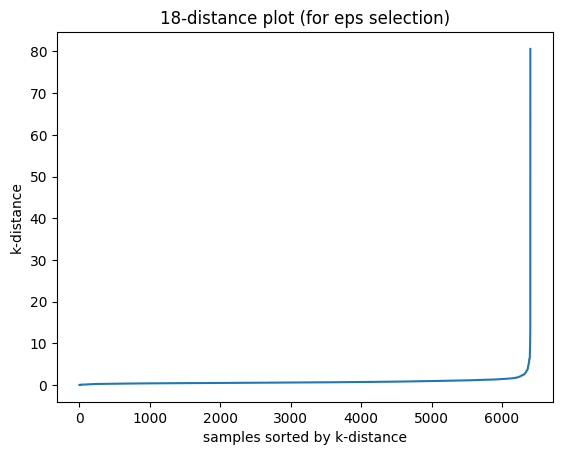

,eps,n_clusters,n_noise,noise_frac,silhouette
0,0.464932,37,3272,0.510851,0.184004
1,0.613939,23,1948,0.304137,0.101553
2,0.762947,16,1350,0.210773,0.107318
3,0.911954,11,890,0.138954,-0.008820
4,1.060962,9,486,0.075878,-0.133179
5,1.209970,8,282,0.044028,-0.081532
6,1.358977,8,219,0.034192,-0.082787
7,1.507985,8,127,0.019828,0.120944


In [24]:
min_samples = max(5, 2 * X_pca.shape[1]) # heuristic for min samples, with min of 5

nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_pca)
distances, indices = nbrs.kneighbors(X_pca)
kdist = np.sort(distances[:, -1])  # distance to k-th neighbor
plt.plot(kdist)
plt.title(f"{min_samples}-distance plot (for eps selection)")
plt.ylabel("k-distance")
plt.xlabel("samples sorted by k-distance")
plt.show()

# DBSCAN: choose eps, eps candidates based on distribution of kdist
eps_candidates = np.linspace(np.percentile(kdist, 30), np.percentile(kdist, 95), 8)

results = []
for eps in eps_candidates:
    db = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
    labels_db = db.fit_predict(X_pca)
    if -1 in labels_db:
        n_clusters = len(set(labels_db)) - 1
    else:
        n_clusters = len(set(labels_db))
    n_noise = list(labels_db).count(-1)
    noise_frac = n_noise / len(labels_db)
    mask_core = labels_db != -1
    if mask_core.sum() > 1 and n_clusters > 1:
        sil = silhouette_score(X_pca[mask_core], labels_db[mask_core])
    else:
        sil = np.nan
    results.append((eps, n_clusters, n_noise, noise_frac, sil))
results_df = pd.DataFrame(results, columns=['eps', 'n_clusters', 'n_noise', 'noise_frac', 'silhouette'])
display(results_df)

Applied DBSCAN to the PCA space to look for density based structure and to treat spatially sparse points as noise rather than forcing them into partitions. To select eps we computed the k-distance plot with k = max(5, 2 * n_components) as the heuristic and evaluated a list of candidate eps values by recording the number of clusters, noise fraction and silhouette score for core points. Then chose the candidates with reasonable noise fraction then maximizing silhouette, producing one very large cluster and several smaller clusters. The DBSCAN cluster summaries on raw features show different cluster profiles, such as one DBSCAN core cluster having a small mean sq_feet and high amenity counts while another has larger sqft. So, the results show the expected DBSCAN tradeoff, where smaller eps lead to many tiny clusters with a higher noise fraction, and larger erps result in fewer clusters with less noise. DBSCAN is useful here to flag small but significant sub populations and to clearly mark noise points, which complements KMeans’ more global partitioning that isolates local dense structures. 

Chosen eps for DBSCAN:  1.5079847643810402
DBSCAN eps=1.5079847643810402 => clusters: 8, noise: 127
DBSCAN eps=1.5079847643810402 -> silhouette: 0.12094382069499497, CH: 172.20232407297172, DB: 0.7124070427632199
DBSCAN cluster sizes (including noise=-1):


-1     127
 0    6012
 1      20
 2      51
 3      25
 4      29
 5      19
 6      56
 7      66
Name: count, dtype: int64

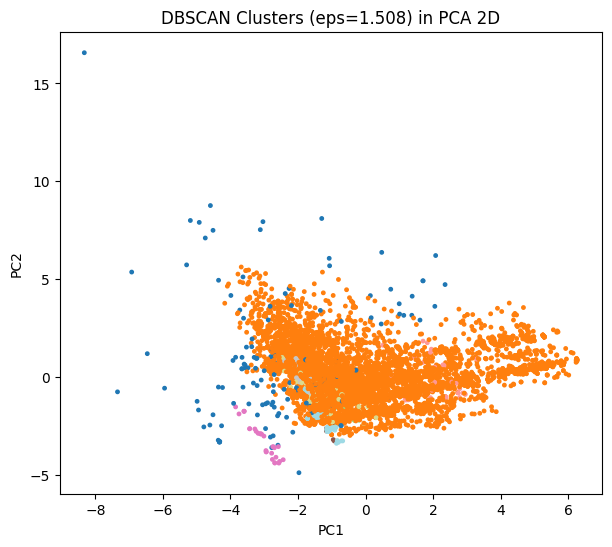

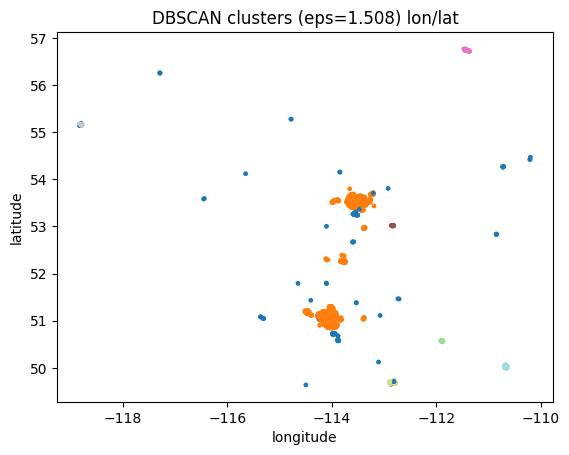

In [26]:
# pick eps by choosing candidate w/ highest silhouette among those w/ reasonable noise_frac < 0.3 and n_clusters > 1
candidates = results_df[(results_df['noise_frac'] < 0.3) & (results_df['n_clusters'] > 1)].copy()

if not candidates.empty and candidates['silhouette'].notna().any():
    best_eps = candidates.loc[candidates['silhouette'].idxmax(), 'eps']
else: # just do median as a backup
    best_eps = float(np.median(eps_candidates))
print("Chosen eps for DBSCAN: ", best_eps)

db_final = DBSCAN(eps=best_eps, min_samples=min_samples)
db_labels = db_final.fit_predict(X_pca)
df_for_clustering[f'dbscan_eps_{round(best_eps, 3)}'] = db_labels

db_labels = df_for_clustering[f'dbscan_eps_{round(best_eps, 3)}'].values
if -1 in db_labels:
    n_clusters_db = len(set(db_labels)) - 1
else:
    n_clusters_db = len(set(db_labels))
n_noise = list(db_labels).count(-1)
print(f"DBSCAN eps={best_eps} => clusters: {n_clusters_db}, noise: {n_noise}")

# metrics
core_mask = db_labels != -1
if core_mask.sum() > 1 and len(set(db_labels[core_mask])) > 1:
    sil_db = silhouette_score(X_pca[core_mask], db_labels[core_mask])
    ch_db = calinski_harabasz_score(X_pca[core_mask], db_labels[core_mask]) 
    db_db = davies_bouldin_score(X_pca[core_mask], db_labels[core_mask])
else:
    sil_db = np.nan
    ch_db = np.nan
    db_db = np.nan

print(f"DBSCAN eps={eps} -> silhouette: {sil_db}, CH: {ch_db}, DB: {db_db}")

# sizes
print("DBSCAN cluster sizes (including noise=-1):")
display(pd.Series(db_labels).value_counts().sort_index())

# visualize DBSCAN on PCA (noise is grey)
plt.figure(figsize=(7,6))
plt.scatter(X_pca2[:, 0], X_pca2[:,1], c=db_labels, cmap= 'tab20', s=6)
plt.title(f"DBSCAN Clusters (eps={round(best_eps, 3)}) in PCA 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()
# visualize on map (noise in grey)
plt.scatter(df_for_clustering['longitude'], df_for_clustering['latitude'], c=db_labels, cmap='tab20', s=6)
plt.title(f"DBSCAN clusters (eps={round(best_eps, 3)}) lon/lat")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.show()


Chosen eps of 1.508 balances a reasonable number of clusters of 8, with a low noise fraction of around 3% as well. Using this, the cluster sizes were roughly 6012, 20, 51, 25, 19, 29, 56, which indicates a very large main cluster alongisde many smaller clusters, which is expected as it's capturing a city's typical large population core in one area, with multiple smaller clusters of listings around it.

IsolationForest outliers: 193
 LOF outliers: 193
Intersection of outliers:  16


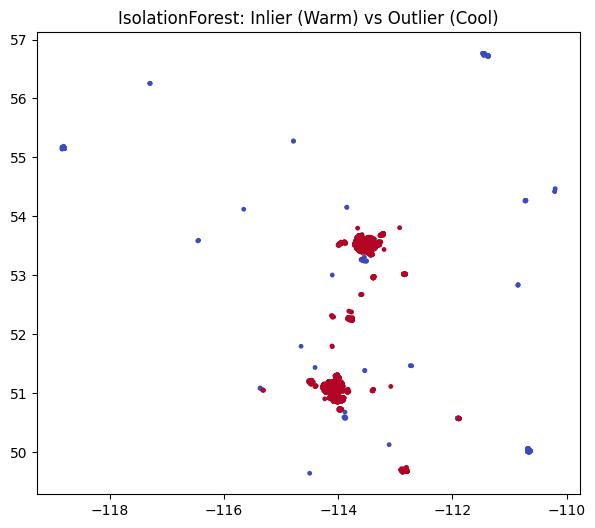

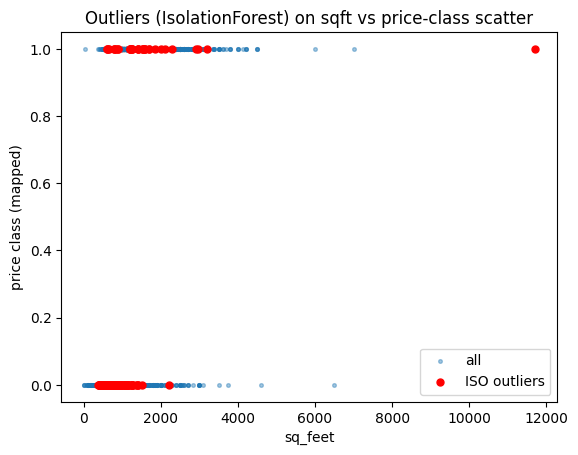

,latitude,longitude,price,sq_feet,beds,baths,restaurantCount,shopCount
1570,51.028096,-114.195080,>=2000,11700,8,7.5,11,0
3690,51.086560,-115.361126,>=2000,1555,3,3.5,62,14
3691,51.080963,-115.367601,>=2000,1200,3,1.5,32,10
3692,51.053566,-115.323189,>=2000,2959,3,3.5,1,1
3693,51.049530,-115.311419,>=2000,2003,4,3.5,1,1
3764,49.638942,-114.497197,>=2000,3200,5,4.0,5,0
5682,53.592716,-116.441155,<2000,1400,2,1.0,1,0
5683,53.583858,-116.455695,>=2000,1398,4,2.0,0,0
5765,53.303801,-113.545295,<2000,450,0,1.0,24,42
5768,53.305023,-113.543151,<2000,450,0,1.0,24,42


In [28]:
# IsolationForest
iso = IsolationForest(contamination=0.03, random_state=seed).fit(X_pca)
iso_labels = iso.fit_predict(X_pca)
df_for_clustering['iso_outlier'] = (iso_labels == -1) # outliers will be -1, inliers 1

# LocalOutlierFactor
lof = LocalOutlierFactor(n_neighbors=30, contamination=0.03) 
lof_labels = lof.fit_predict(X_pca)  # -1 outlier, 1 inlier
df_for_clustering['lof_outlier'] = (lof_labels == -1)

print("IsolationForest outliers:", df_for_clustering['iso_outlier'].sum())
print(" LOF outliers:", df_for_clustering['lof_outlier'].sum())

# intersectioning for higher confidence
df_for_clustering['outlier_both'] = df_for_clustering['iso_outlier'] & df_for_clustering['lof_outlier']
print("Intersection of outliers: ", df_for_clustering['outlier_both'].sum())

# Visualize isolationforest inlier vs outlier
plt.figure(figsize=(7,6))
plt.scatter(df_for_clustering['longitude'], df_for_clustering['latitude'], c=~df_for_clustering['iso_outlier'], cmap='coolwarm', s=6)
plt.title("IsolationForest: Inlier (Warm) vs Outlier (Cool)")
plt.show()

# Price vs sq_feet showing outliers highlighted
plt.scatter(df_for_clustering['sq_feet'], df_for_clustering['price'].map({'<2000':0, '>=2000':1}), s=7, alpha=0.4, label='all')
plt.scatter(df_for_clustering.loc[df_for_clustering['iso_outlier'],'sq_feet'],
            df_for_clustering.loc[df_for_clustering['iso_outlier'],'price'].map({'<2000':0, '>=2000':1}),
            s=25, c='red', label='ISO outliers')
plt.xlabel("sq_feet"); plt.ylabel("price class (mapped)")
plt.legend()
plt.title("Outliers (IsolationForest) on sqft vs price-class scatter")
plt.show()

display(df_for_clustering.loc[df_for_clustering['outlier_both']].head(20)[['latitude', 'longitude', 'price', 'sq_feet', 'beds', 'baths', 
                                                                           'restaurantCount', 'shopCount']])

Applied two complementary unsupervised outlier detectors IsolationForest and LocalOutlierFactor on the PCA space to highlight any abnormal listings. Using two methods and intersecting results increases precision of outlier identification. The detectors were run with contamination=0.03, which is conservative, resulting in IsolationForest flagging 193 outliers, and LocalOutlierFactor flagging 193 as well. In the intersection, 16 listings were flagged by both methods marked separately as higher confidence outliers. The number of outliers being just under 200 in comparison to the original dataset for clustering of 6405 aligns with the contamination set earlier. The intersection being only 16 could suggest that teh two algorithms have different sensitivities, likely IsolationForest looking towards more global anomalies, where as LocalOutlierFactor emphasizes more local amenities, which is expected. The intersection created should result in a set of outliers that are worth manually inspecting to determine future action. Importantly, these outliers are only highlighted, not removed, with the exception of invalid 0 sqft values for certain listings, allowing for manual inspection of outliers, since large square footage or beds could be explained by something like a mansion, which is a completely valid listing. Additionally, high amenity counts flagged as outliers could very reasonably represent high traffic commercial spaces, such as shopping centres. Distinct flags are set for this purpose, iso_outlier, lof_outlier, outlier_both, if additional examination is required. Visualizing the outliers on scatterplots with longitude and latitude, as well as price vs sqft with the outliers highlighted help in determining whether or not the outlier may be valid, such as an expensive penthouse, or an actual outlier.

In [30]:
# KMeans summary (raw features)
km_summary = df_for_clustering.groupby('kmeans_cluster').agg({
    'sq_feet':'mean','beds':'mean','baths':'mean','restaurantCount':'mean','shopCount':'mean',
    'nearestSchool':'mean','nearestPolice':'mean','price':lambda s: (s==">=2000").mean()
}).rename(columns={'price':'pct_ge_2000'}).round(3)
print("KMeans cluster summary (raw feature means):")
display(km_summary)

# DBSCAN summary (only for core labels, label -1 is noise)
db_label_col = f'dbscan_eps_{round(best_eps,3)}'
if db_label_col in df_for_clustering.columns:
    db_summary = df_for_clustering[df_for_clustering[db_label_col] != -1].groupby(db_label_col).agg({
        'sq_feet':'mean','beds':'mean','baths':'mean','restaurantCount':'mean','shopCount':'mean',
        'nearestSchool':'mean','nearestPolice':'mean','price':lambda s: (s==">=2000").mean()
    }).rename(columns={'price':'pct_ge_2000'}).round(3)
    print("DBSCAN cluster summary (core points only):")
    display(db_summary.head(20))
else:
    print("DBSCAN label column not found; skipped DBSCAN summary.")

KMeans cluster summary (raw feature means):


,sq_feet,beds,baths,restaurantCount,shopCount,nearestSchool,nearestPolice,pct_ge_2000
kmeans_cluster,,,,,,,,
0,1120.824,2.185,1.674,23.368,4.738,4.531,10.160,0.448
1,808.981,1.504,1.340,216.447,31.416,0.924,1.739,0.512


DBSCAN cluster summary (core points only):


,sq_feet,beds,baths,restaurantCount,shopCount,nearestSchool,nearestPolice,pct_ge_2000
dbscan_eps_1.508,,,,,,,,
0,1032.705,1.999,1.588,77.415,12.177,3.331,5.878,0.477
1,681.500,1.500,1.000,7.000,3.900,0.977,60.922,0.050
2,845.333,1.824,1.608,79.255,14.922,1.155,2.196,0.824
3,715.400,1.560,1.000,16.080,2.920,1.245,53.938,0.000
4,940.655,2.034,1.466,9.414,1.793,3.126,100.717,0.172
5,908.632,2.053,1.184,6.947,0.684,1.734,153.037,0.000
6,790.054,1.714,1.134,10.304,2.357,3.170,40.211,0.036
7,754.136,1.530,1.030,5.561,2.879,3.372,2.652,0.015


KMeans, with k=2 gives a robust broader segmentation, with 2 reasonable groups wiht a moderate silhouette of 0.332, and DBSCAN reveals smaller, denser pockets, with lots of points in a huge main cluster plus several small dense clusters. Could utilise both, with the KMeans for higher level stratification, and DBSCAN to find localised dense subpopulations and anomalies. The outlier methods, IsolationForest and LOF, produces a conservative set of flagged entries for manual review. Practically, the KMeans cluster label can be used for higher-level stratification and use the DBSCAN clusters to highlight local special cases, like submarket niches, and treat outlier_both as high-priority candidates for data cleaning or closer insepction.